# **Project 2b − Bayesian Optimization of Ad-Atom Energy Landscapes**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [988]:

# Imports
import ase
import asap3
import GPy

import numpy as np
import matplotlib.pyplot as plt
import scipy
from tqdm import tqdm

# Latex plotting settings
plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'palatino'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['ytick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# General functions
def calculate_adatom_energy(surface, position):
    """Adds adatom to the input surface configuration at the given position
    and relaxes the ad-atoms z-coordinate.

    Parameters
    ----------
    bare_surface
        surface configuration without adatom
    position
        position (x, y, z) at which to insert adatom in Ångström

    Returns
    -------
    tuple comprising the energy of the adatom configuration
    """
    # add adatom
    surface_with_adatom = surface.copy()
    surface_with_adatom.append(ase.Atom('Au', position))

    # attach calculator
    calc = asap3.EMT()
    surface_with_adatom.set_calculator(calc)

    # apply constraints
    constraints = []
    c = ase.constraints.FixAtoms(indices=list(range(len(surface_with_adatom) - 1)))
    constraints.append(c)
    c = ase.constraints.FixedLine(-1, [0, 0, 1])
    constraints.append(c)

    # relax configuration
    surface_with_adatom.set_constraint(constraints)
    dyn = ase.optimize.BFGS(surface_with_adatom, logfile=None)
    dyn.run(fmax=0.02, steps=200)

    energy = surface_with_adatom.get_potential_energy()
    
    return energy


## **Task 1: Analyzing the PES**

In [ ]:

# Read surface configuration and set up grid
surface = ase.io.read('data/surface_supercell.xyz')
xmax, ymax = 16.65653, 2.884996
d_xy = 0.02 # grid spacing in Ångström
z_top = surface.get_positions()[:, 2].max() + 3.0 # initial z-position of adatom
x = np.linspace(0, xmax, int(xmax/d_xy) + 1)
y = np.linspace(0, ymax, int(ymax/d_xy) + 1)
X, Y = np.meshgrid(x, y) # create grid
print(f'Grid shape: {X.shape}')

def compute_energy_grid(surface, x, y):
    '''
    Computes the energy grid for an adatom on the given surface configuration.

    Args:
        surface: ASE Atoms object representing the surface configuration.
        x: 2D numpy array of x-coordinates on the grid.
        y: 2D numpy array of y-coordinates on the grid.
    
    Returns:
        2D numpy array of energy values corresponding to each (x, y) position.
    '''

    energy_grid = np.zeros(x.shape) # initialize energy grid
    for i in tqdm(range(x.shape[0]), desc=f'Computing energy grid'):
        for j in range(x.shape[1]):
            energy_grid[i, j] = calculate_adatom_energy(surface, [x[i, j], y[i, j], z_top]) # compute energy at (x, y)

    return energy_grid

# Compute energy grid
energy_grid = compute_energy_grid(surface, X, Y)


Grid shape: (145, 833)


Computing energy grid: 100%|██████████| 145/145 [1:14:49<00:00, 30.96s/it]


Global minimum position: x = 3.263 Å, y = 0.721 Å
Global minimum energy: 7.075158683619714 eV


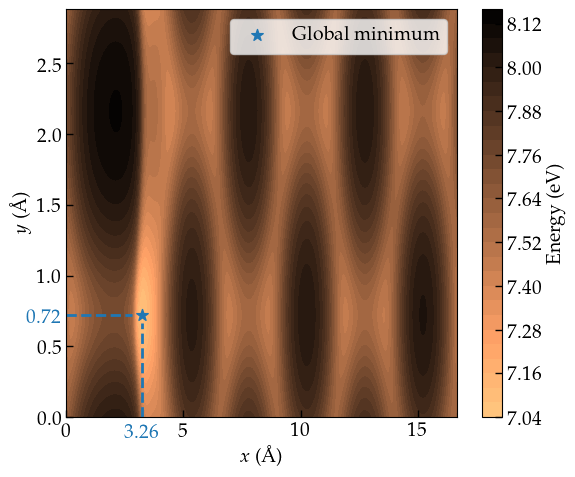

In [ ]:

# Find global minimum and plot energy surface
global_min = np.min(energy_grid)
global_min_pos = np.unravel_index(np.argmin(energy_grid), energy_grid.shape)
print(f'Global minimum position: x = {X[global_min_pos]:.3f} Å, y = {Y[global_min_pos]:.3f} Å')
print(f'Global minimum energy: {global_min} eV')

# Plot energy surface
plt.figure(figsize=(6, 5))
cp = plt.contourf(X, Y, energy_grid, levels=30, cmap='copper_r')
plt.colorbar(cp, label='Energy (eV)')
plt.xlabel('$x$ (Å)', fontsize=font_size)
plt.ylabel('$y$ (Å)', fontsize=font_size)
plt.scatter(X[global_min_pos], Y[global_min_pos], color='tab:blue', marker='*', s=75, label='Global minimum')
plt.axhline(y=Y[global_min_pos], xmax=0.17, color='tab:blue', linestyle='--', linewidth=2)
plt.text(X[global_min_pos]-0.8, -0.14, f'{X[global_min_pos]:.2f}', color='tab:blue', fontsize=font_size)
plt.axvline(x=X[global_min_pos], ymax=0.23, color='tab:blue', linestyle='--', linewidth=2)
plt.text(-1.7, Y[global_min_pos]-0.05, f'{Y[global_min_pos]:.2f}', color='tab:blue', fontsize=font_size)
plt.legend()

plt.tight_layout()
# plt.savefig('figs/energy_surface.pdf')
plt.show()


## **Task 2: Local search**

In [ ]:

# Local BFGS optimization searches
n_searches = 500 # number of local optimizations
rng = np.random.default_rng(19)
tol = 0.05 # tolerance for considering a minimum as global
indices = rng.choice(energy_grid.size, size=(n_searches, 2), replace=False) # random starting indices

def objective_function(pos):
    '''
    Objective function for local optimization.
    
    Args:
        pos: list or array-like of length 2, representing the (x, y) coordinates.
        
    Returns:
        Energy value at the given (x, y) position with adatom at z_top.
    '''
    # Unpack position
    x, y = pos[0], pos[1]
    
    return calculate_adatom_energy(surface, [x, y, z_top])

def callback(xk):
    '''
    Callback function to store trajectory during optimization.
    
    Args:
        xk: current position during optimization.
    '''

    trajectory.append(xk)

glob_found = 0 # counter for number of global minima found
min_positions = [] # list to store starting and found minimum positions
trajs = [] # store all trajectories
for n in tqdm(range(n_searches)):
    # Get starting position from random indices
    x_start = X.ravel()[indices[n, 0]] 
    y_start = Y.ravel()[indices[n, 1]]
    trajectory = [] # to store trajectory for this optimization

    # Perform local optimization
    result = scipy.optimize.minimize(objective_function, [x_start, y_start], method='L-BFGS-B',
                                     bounds=[(0, xmax), (0, ymax)], callback=callback)
    min_x, min_y = result.x # found minimum position
    min_position = [min_x, min_y]
    min_positions.append([x_start, y_start] + min_position)
    trajs.append(trajectory)

    # Check if found minimum is global
    min_energy = calculate_adatom_energy(surface, [min_x, min_y, z_top])
    if abs(min_energy - global_min) < tol:
        glob_found += 1

print(f'Found global minimum in {glob_found} out of {n_searches} searches.')


100%|██████████| 500/500 [10:57<00:00,  1.31s/it]

Found global minimum in 67 out of 500 searches.


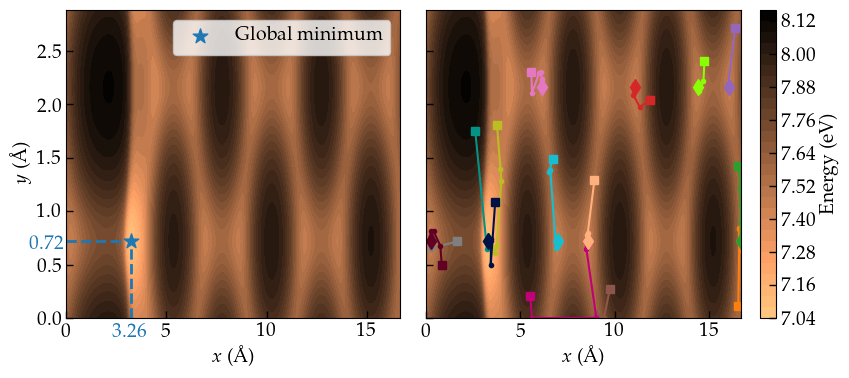

In [ ]:

# Plot some trajectories on energy surface
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'xkcd:burgundy', 'xkcd:teal', 'xkcd:magenta', 'xkcd:lime green', 'xkcd:navy blue', 'xkcd:peach', 'xkcd:lavender', 'xkcd:mustard yellow', 'xkcd:sky blue', 'xkcd:coral', 'xkcd:forest green']
rng = np.random.default_rng(19)
plot_traj_indices = rng.integers(0, n_searches, size=15) # indices of trajectories to plot

# Plot energy surface
fig, axs = plt.subplots(1, 2, figsize=(8.8, 4), sharey=True, gridspec_kw={'width_ratios': [0.85, 1]})
cp = axs[0].contourf(X, Y, energy_grid, levels=30, cmap='copper_r')
axs[0].scatter(X[global_min_pos], Y[global_min_pos], color='tab:blue', marker='*', s=120, label='Global minimum', zorder=5)
axs[0].set_xlabel('$x$ (Å)', fontsize=font_size)
axs[0].set_ylabel('$y$ (Å)', fontsize=font_size)
axs[0].axhline(y=Y[global_min_pos], xmax=0.17, color='tab:blue', linestyle='--', linewidth=2)
axs[0].text(X[global_min_pos]-0.98, -0.175, f'{X[global_min_pos]:.2f}', color='tab:blue', fontsize=font_size)
axs[0].axvline(x=X[global_min_pos], ymax=0.23, color='tab:blue', linestyle='--', linewidth=2)
axs[0].text(-1.85, Y[global_min_pos]-0.07, f'{Y[global_min_pos]:.2f}', color='tab:blue', fontsize=font_size)
axs[0].legend()

# Plot energy surface with trajectories
cp = axs[1].contourf(X, Y, energy_grid, levels=30, cmap='copper_r')
fig.colorbar(cp, ax=axs[1], label='Energy (eV)')
for i, idx in enumerate(plot_traj_indices):
    traj = np.array(trajs[idx])
    axs[1].plot(traj[:, 0], traj[:, 1], marker='o', markersize=3, color=colors[i])
    axs[1].plot(traj[0, 0], traj[0, 1], marker='s', markersize=6, color=colors[i]) # starting point
    axs[1].plot(traj[-1, 0], traj[-1, 1], marker='d', markersize=8, color=colors[i]) # found minimum
axs[1].set_xlabel('$x$ (Å)', fontsize=font_size)

plt.tight_layout()
# plt.savefig('figs/energy_surface_with_LBOS_trajectories.pdf')
plt.show()


## **Task 3: Bayesian optimization**

In [ ]:

def A(x, y, model, beta):
    '''
    Acquisition function for Bayesian optimization using GP model.
    
    Args:
        x: 2D numpy array of x-coordinates on the grid.
        y: 2D numpy array of y-coordinates on the grid.
        model: GPy GPRegression model.
        beta: float, exploration-exploitation parameter.
    
    Returns:
        1D numpy array of acquisition function values at each (x, y) position.
    '''

    pos = np.vstack([x.ravel(), y.ravel()]).T # shape (N, 2)
    mu, var = model.predict(pos) # predict mean and variance
    sigma = np.sqrt(var) # standard deviation

    return - mu + beta * sigma

def find_new_sample(A_values, x, y):
    '''
    Finds the (x, y) position corresponding to the maximum acquisition function value.
    
    Args:
        A_values: 1D numpy array of acquisition function values.
        x: 2D numpy array of x-coordinates on the grid.
        y: 2D numpy array of y-coordinates on the grid.
        
    Returns:
        Tuple (x_new, y_new) of coordinates for the new sample.
    '''
 
    index = np.argmax(A_values) # index of maximum A value
    x_new = x.ravel()[index] # corresponding x coordinate
    y_new = y.ravel()[index] # corresponding y coordinate

    return x_new, y_new

def bay_optimizer(kernel, x, y, beta, positions, Es, its, tol):
    '''
    Bayesian optimizer using Gaussian Process regression.
    
    Args:
        kernel: GPy kernel object.
        x: 2D numpy array of x-coordinates on the grid.
        y: 2D numpy array of y-coordinates on the grid.
        beta: float, exploration-exploitation parameter.
        positions: list of initial sampled positions [[x1, y1], [x2, y2], ...].
        Es: list of initial sampled energies [E1, E2, ...].
        its: int, number of iterations to perform.
        tol: float, tolerance for convergence (not used in current implementation).
    
    Returns:
        history: dict containing positions, energies, and A_values over iterations.
        model: trained GPy GPRegression model.
    '''
    
    # Initialize GP model
    model = GPy.models.GPRegression(np.array(positions), np.array(Es).reshape(-1, 1), kernel)
    model.optimize_restarts(verbose=False, num_restarts=10)

    # History storage
    history = {
        'positions': [], 
        'energies': [], 
        'A_values': []
        }
    for i in tqdm(range(its), desc=f'beta = {beta}'):

        A_values = A(x, y, model, beta) # compute acquisition function
        new_x, new_y = find_new_sample(A_values, x, y) # find new sample position
        new_position = [new_x, new_y, z_top]
        new_energy = calculate_adatom_energy(surface, new_position) # evaluate new sample

        positions.append([new_x, new_y]) # add new position
        Es.append(new_energy) # add new energy

        model.set_XY(np.array(positions), np.array(Es).reshape(-1, 1)) # update model

        # Optimize model hyperparameters every 5 iterations
        if i % 5 == 0:
            model.optimize_restarts(verbose=False, num_restarts=5)

        # Store history
        history['positions'].append([new_x, new_y])
        history['energies'].append(new_energy)
        history['A_values'].append(A(new_x, new_y, model, beta))

        # # Check convergence (optional)
        # last_5_diffs = np.array([abs(e - new_energy) for e in Es[-5:]])
        # if np.all(last_5_diffs < tol):
        #     print('Convergence reached.')
        #     return history, model
        
    return history, model


In [983]:

betas = [0.5, 1, 2, 3, 5, 10] # exploration-exploitation parameters
n_samples = 5 # initial random samples
rng = np.random.default_rng(19)
indices = rng.choice(X.size, size=n_samples, replace=False)

delta_E = np.max(energy_grid) - np.min(energy_grid)
var0 = (delta_E / 2) ** 2 # initial variance prior
print(f'Initial variance prior set to: {var0} eV^2')


Initial variance prior set to: 0.27483753281055295 eV^2


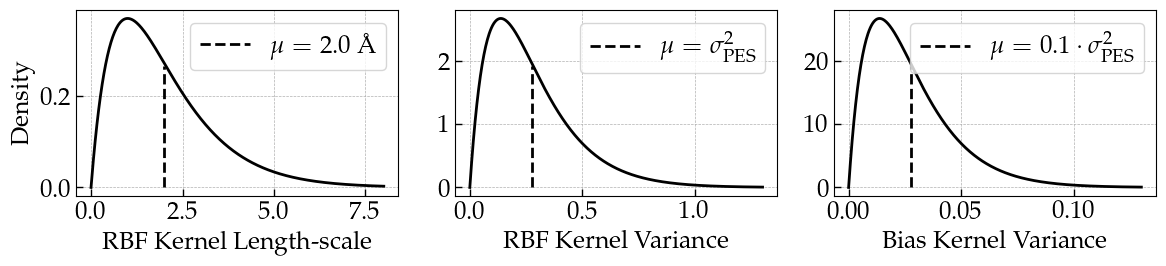

In [984]:

# Plot hyperparameter priors using scipy
x_ls = np.linspace(0, 8, 500)
x_var = np.linspace(0, 1.3, 500)
x_varbias = np.linspace(0, 0.13, 500)

ls_prior = scipy.stats.gamma.pdf(x_ls, 2.0, scale=1.0)
var_prior = scipy.stats.gamma.pdf(x_var, 2.0, scale=var0 / 2)
varbias_prior = scipy.stats.gamma.pdf(x_varbias, 2.0, scale=var0 * 0.1 / 2.0)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(x_ls, ls_prior, color='k', linewidth=2)
axs[0].axvline(x=2.0, ymin=0.05, ymax=0.7, color='k', linestyle='--', linewidth=2, label=r'$\mu = 2.0$ Å')
axs[0].set_xlabel('RBF Kernel Length-scale', fontsize=font_size)
axs[0].set_ylabel('Density', fontsize=font_size)
axs[0].legend()
axs[0].grid(True, linestyle='--', linewidth=0.5)
axs[1].plot(x_var, var_prior, color='k', linewidth=2)
axs[1].axvline(x=var0, ymin=0.05, ymax=0.7, color='k', linestyle='--', linewidth=2, label=r'$\mu = \sigma_{\text{PES}}^2$')
axs[1].set_xlabel('RBF Kernel Variance', fontsize=font_size)
axs[1].legend()
axs[1].grid(True, linestyle='--', linewidth=0.5)
axs[2].plot(x_varbias, varbias_prior, color='k', linewidth=2)
axs[2].axvline(x=var0 * 0.1, ymin=0.05, ymax=0.7, color='k', linestyle='--', linewidth=2, label=r'$\mu = 0.1 \cdot \sigma_{\text{PES}}^2$')
axs[2].set_xlabel('Bias Kernel Variance', fontsize=font_size)
axs[2].legend()

axs[2].grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('figs/hyperparameter_priors.pdf')
plt.show()


In [985]:

# Run Bayesian optimizations for different beta values
results = {
    'beta': [],
    'positions': [],
    'energies': [],
    'A_values': []
    }
for beta in betas:
    # Define kernel with priors
    k1 = GPy.kern.RBF(input_dim=2)
    k1['lengthscale'].set_prior(GPy.priors.Gamma(2.0, 1.0), warning=False)
    k1['variance'].set_prior(GPy.priors.Gamma(2.0, var0 / 2.0), warning=False)
    k2 = GPy.kern.Bias(input_dim=2)
    k2['variance'].set_prior(GPy.priors.Gamma(2.0, var0 * 0.1 / 2.0), warning=False)
    kernel = k1 + k2

    # Initial samples
    positions = [[X.ravel()[i], Y.ravel()[i]] for i in indices]
    energies = [calculate_adatom_energy(surface, [X.ravel()[i], Y.ravel()[i], z_top]) for i in indices]
    
    # Run optimizer and store results
    history, model = bay_optimizer(kernel, X, Y, beta=beta, positions=positions, Es=energies, its=50, tol=1e-6)
    results['beta'].append(beta)
    results['positions'].append(history['positions'])
    results['energies'].append(history['energies'])
    results['A_values'].append(history['A_values'])


beta = 1:  10%|█         | 5/50 [00:01<00:08,  5.14it/s] /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/stationary.py:168: RuntimeWarning:overflow encountered in divide
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/rbf.py:52: RuntimeWarning:overflow encountered in square
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/rbf.py:178: RuntimeWarning:invalid value encountered in multiply
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/core/parameterization/priorizable.py:81: RuntimeWarning:overflow encountered in scalar add
beta = 10: 100%|██████████| 50/50 [00:23<00:00,  2.10it/s]


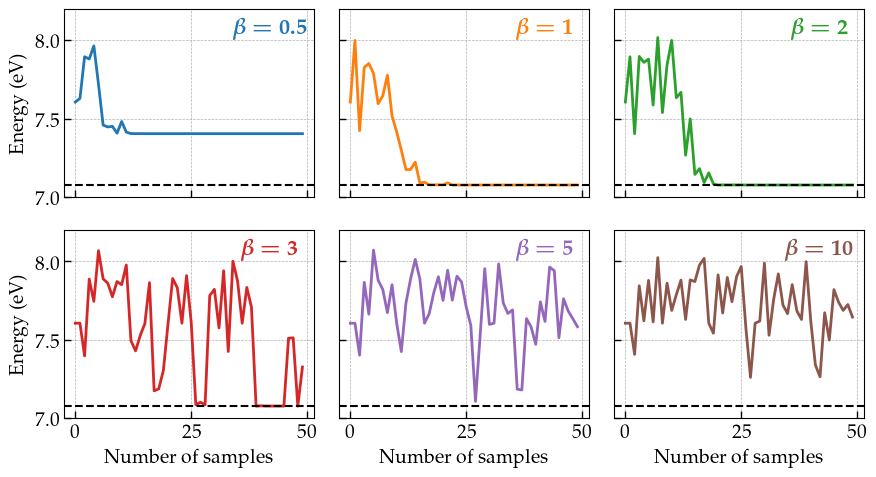

In [989]:

# Plot energy convergence for different beta values
ncols = 3
fig, axs = plt.subplots(2, ncols, figsize=(9, 5), sharex=True, sharey=True)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
for i, beta in enumerate(betas):
    positions = results['positions'][i]
    energies = results['energies'][i]
    A_values = np.array(results['A_values'][i]).flatten()

    axs[i // ncols, i % ncols].plot(np.arange(len(energies)), energies, color=colors[i], linewidth=2)
    axs[i // ncols, i % ncols].axhline(global_min, color='k', linestyle='--')
    axs[i // ncols, i % ncols].text(0.82, 0.9, r'$\bm{\beta = }' + f'\\bm{{{beta}}}' + '$', horizontalalignment='center', verticalalignment='center', transform=axs[i // ncols, i % ncols].transAxes, fontsize=font_size+2, color=colors[i])
    if i // ncols == 1:
        axs[i // ncols, i % ncols].set_xlabel('Number of samples', fontsize=font_size)
    if i % ncols == 0:
        axs[i // ncols, i % ncols].set_ylabel('Energy (eV)', fontsize=font_size)
    axs[i // ncols, i % ncols].grid(True, which='both', linestyle='--', linewidth=0.5)
    axs[i // ncols, i % ncols].set_xticks([0, 25, 50])
    axs[i // ncols, i % ncols].set_ylim(7, 8.2)

plt.tight_layout()
# plt.savefig('figs/LBOS_energy_convergence.pdf')
plt.show()


In [ ]:

# Single run for optimal beta = 2
beta = 2

# Define kernel with priors
k1 = GPy.kern.RBF(input_dim=2)
k1['lengthscale'].set_prior(GPy.priors.Gamma(2.0, 1.0), warning=False)
k1['variance'].set_prior(GPy.priors.Gamma(2.0, var0 / 2.0), warning=False)
k2 = GPy.kern.Bias(input_dim=2)
k2['variance'].set_prior(GPy.priors.Gamma(2.0, var0 * 0.1 / 2.0), warning=False)
kernel = k1 + k2
    
n_initial_samples = 5 # initial random samples
rng = np.random.default_rng(19)
indices = rng.choice(X.size, size=n_initial_samples, replace=False)
positions = [[X.ravel()[i], Y.ravel()[i]] for i in indices]
energies = [calculate_adatom_energy(surface, [X.ravel()[i], Y.ravel()[i], z_top]) for i in indices]

# Run optimizer
history, model = bay_optimizer(kernel, X, Y, beta=beta, positions=positions, Es=energies, its=50, tol=1e-6)


beta = 2:  60%|██████    | 30/50 [00:10<00:07,  2.66it/s] /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/stationary.py:168: RuntimeWarning:overflow encountered in divide
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/rbf.py:52: RuntimeWarning:overflow encountered in square
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/rbf.py:178: RuntimeWarning:invalid value encountered in multiply
beta = 2: 100%|██████████| 50/50 [00:21<00:00,  2.36it/s]


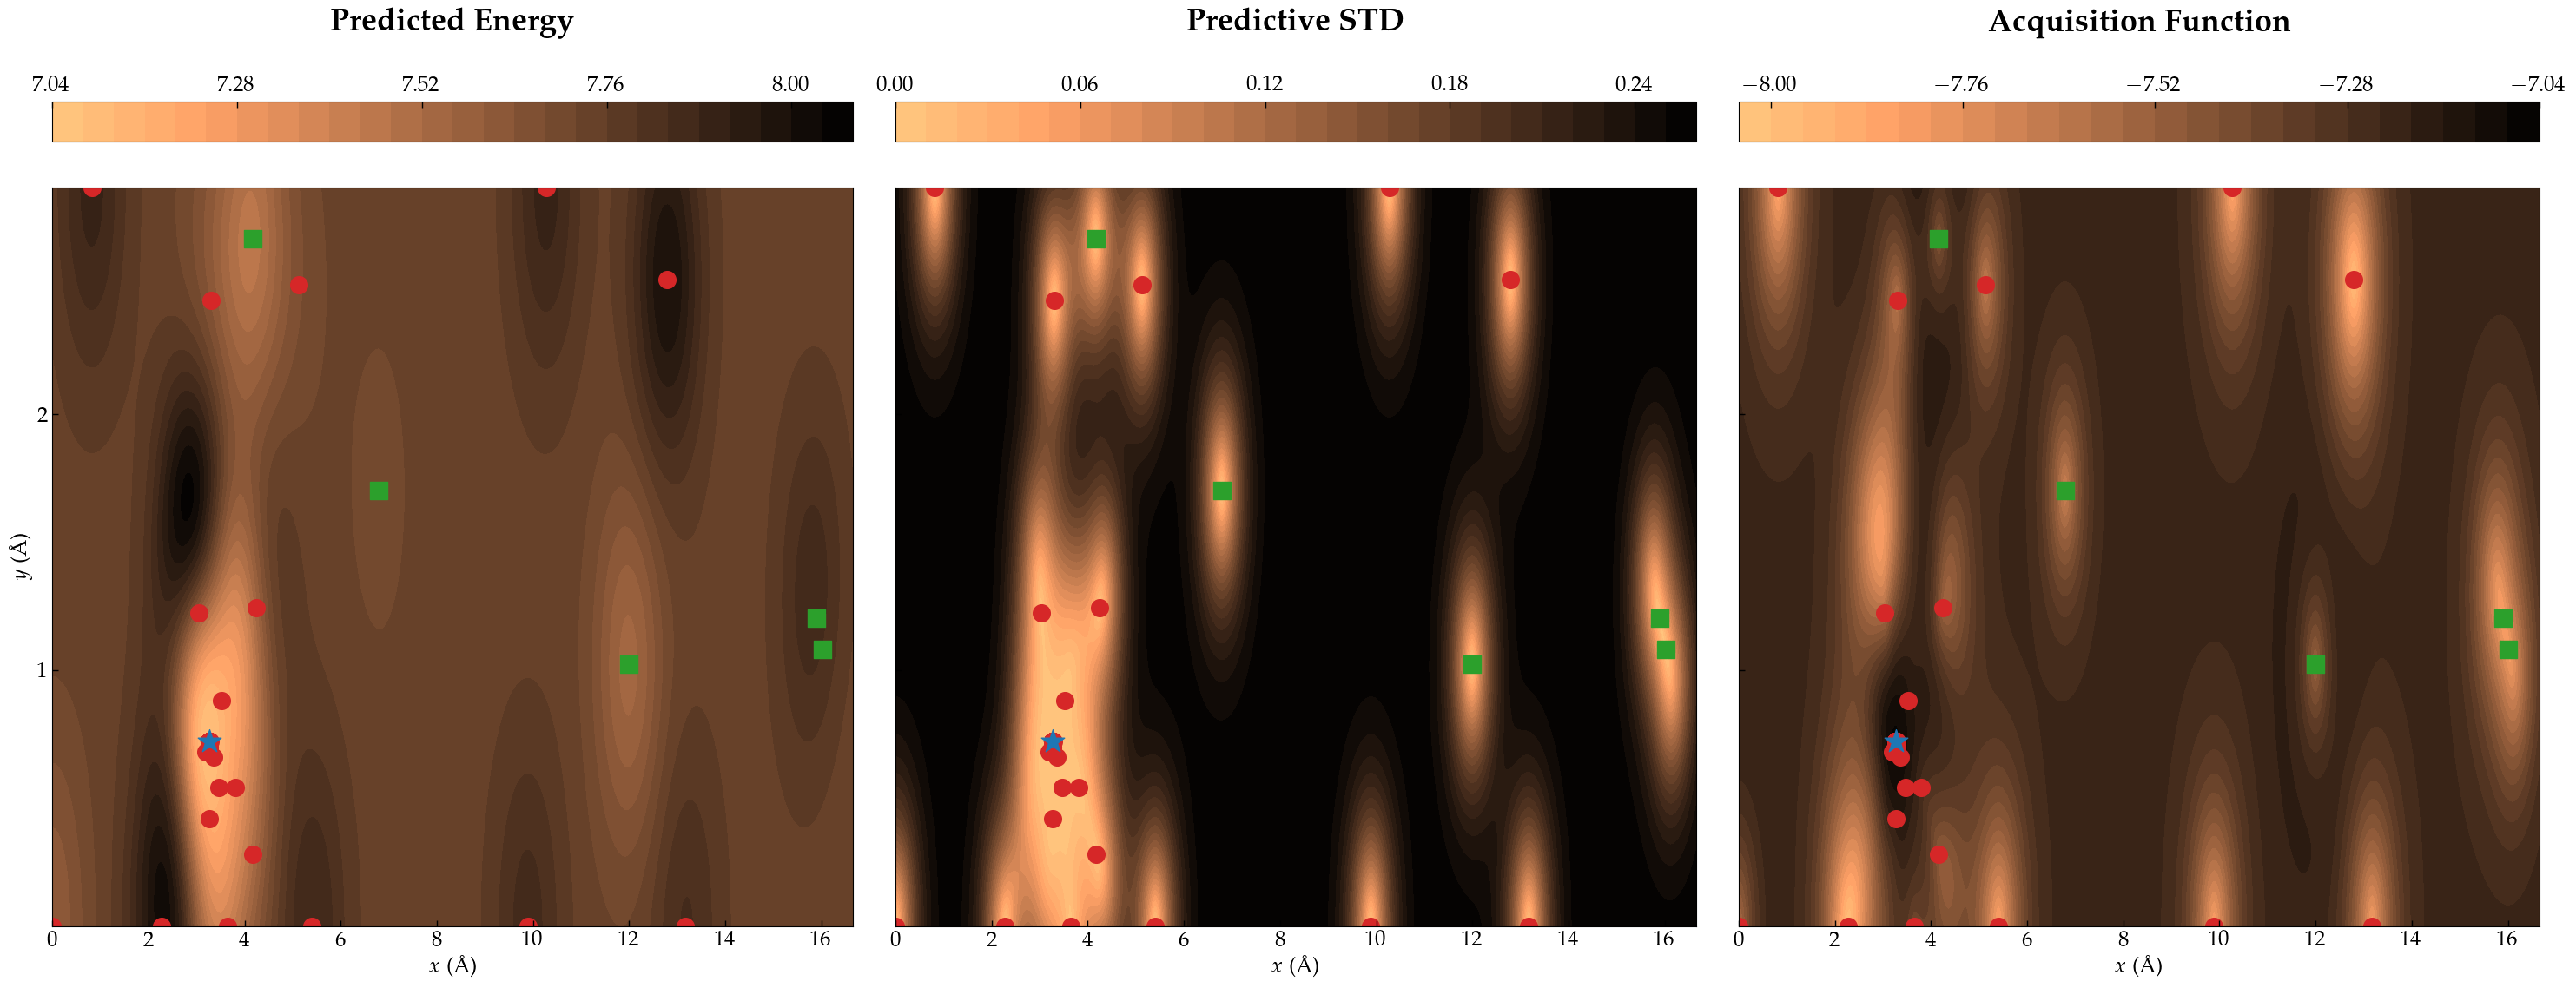

In [ ]:

# Plot GP model analysis
grid_positions = np.vstack([X.ravel(), Y.ravel()]).T # shape (N, 2)
mean_pred_grid, var_pred_grid = model.predict(grid_positions) # predict on grid

fig, axs = plt.subplots(1, 3, figsize=(30, 12), sharey=True)
cp = axs[0].contourf(X, Y, mean_pred_grid.reshape(X.shape), levels=30, cmap='copper_r') # plot predicted mean
fig.colorbar(cp, ax=axs[0], location='top', ticks=[7.04, 7.28, 7.52, 7.76, 8.0])
axs[0].set_xlabel('$x$ (Å)', fontsize=font_size)
axs[0].set_ylabel('$y$ (Å)', fontsize=font_size)
axs[0].scatter(X[global_min_pos], Y[global_min_pos], color='tab:blue', marker='*', s=400, zorder=5) # global minimum
axs[0].scatter(np.array(history['positions'])[:, 0], np.array(history['positions'])[:, 1], color='tab:red', marker='o', s=200) # sampled points
axs[0].scatter(np.array(positions)[:5, 0], np.array(positions)[:5, 1], color='tab:green', marker='s', s=200) # initial points
axs[0].set_title('\\textbf{Predicted Energy}', fontsize=font_size+8, pad=130) 
axs[0].set_yticks([1, 2])

# Plot predicted standard deviation
cp = axs[1].contourf(X, Y, np.sqrt(var_pred_grid).reshape(X.shape), levels=30, cmap='copper_r')
fig.colorbar(cp, ax=axs[1], location='top', ticks=[0.00, 0.06, 0.12, 0.18, 0.24])
axs[1].scatter(X[global_min_pos], Y[global_min_pos], color='tab:blue', marker='*', s=400, label='Global minimum', zorder=5)
axs[1].scatter(np.array(history['positions'])[:, 0], np.array(history['positions'])[:, 1], color='tab:red', marker='o', s=200, label='Sampled points')
axs[1].scatter(np.array(positions)[:5, 0], np.array(positions)[:5, 1], color='tab:green', marker='s', s=200, label='Initial points')
axs[1].set_xlabel('$x$ (Å)', fontsize=font_size)
axs[1].set_title('\\textbf{Predictive STD}', fontsize=font_size+8, pad=130)

# Plot acquisition function
A_values_grid = A(X, Y, model, beta).reshape(X.shape)
cp = axs[2].contourf(X, Y, A_values_grid, levels=30, cmap='copper_r')
fig.colorbar(cp, ax=axs[2], location='top', ticks=[-8.0, -7.76, -7.52, -7.28, -7.04])
axs[2].scatter(X[global_min_pos], Y[global_min_pos], color='tab:blue', marker='*', s=400, label='Global minimum', zorder=5)
axs[2].scatter(np.array(history['positions'])[:, 0], np.array(history['positions'])[:, 1], color='tab:red', marker='o', s=200, label='Sampled points')
axs[2].scatter(np.array(positions)[:5, 0], np.array(positions)[:5, 1], color='tab:green', marker='s', s=200, label='Initial points')
axs[2].set_xlabel('$x$ (Å)', fontsize=font_size)
axs[2].set_title('\\textbf{Acquisition Function}', fontsize=font_size+8, pad=130)

plt.tight_layout()
# plt.savefig('figs/LBOS_GP_model_analysis.pdf')
plt.show()


## **Task 4: Transition paths barriers**

In [ ]:

# Transition path setup with GP model
n_initial_samples = 5 # number of initial random samples
rng = np.random.RandomState(1337)
Ngrid = X.size # total number of grid points

init_idx = rng.choice(Ngrid, size=n_initial_samples, replace=False) # random initial indices
positions = [[X.ravel()[i], Y.ravel()[i]] for i in init_idx ] # initial positions
Es = [calculate_adatom_energy(surface, [X.ravel()[i], Y.ravel()[i], z_top]) for i in init_idx ] # initial energies

# Add global minimum and end point minimum to training data
start = np.array([X[global_min_pos], Y[global_min_pos]])
end = np.array([11, 2.1])
positions.append([start[0], start[1]])
Es.append(calculate_adatom_energy(surface, [start[0], start[1], z_top]))
positions.append([end[0], end[1]])
Es.append(calculate_adatom_energy(surface, [end[0], end[1], z_top]))

# Define and train GP model
X_train = np.array(positions)
Y_train = np.array(Es).reshape(-1, 1)
k1 = GPy.kern.RBF(input_dim=2) 
k1.lengthscale.set_prior(GPy.priors.Gamma(2.0, 1.0), warning=False)
k1.variance.set_prior(GPy.priors.Gamma(2.0, var0 / 2.0), warning=False)
k2 = GPy.kern.Bias(input_dim=2)
k2['variance'].set_prior(GPy.priors.Gamma(2.0, var0 * 0.1 / 2.0), warning=False)
kernel = k1 + k2

general_model = GPy.models.GPRegression(X_train, Y_train, kernel)
general_model.optimize_restarts(num_restarts=5, verbose=False)
print(general_model)



Name : GP regression
Objective : 19.360190140171184
Number of Parameters : 4
Number of Optimization Parameters : 4
Updates : True
Parameters:
  GP_regression.           |                 value  |  constraints  |     priors   
  sum.rbf.variance         |    0.6944482375721512  |      +ve      |  Ga(2, 0.14) 
  sum.rbf.lengthscale      |    2.1581020750371294  |      +ve      |    Ga(2, 1)  
  sum.bias.variance        |     66.70249414360325  |      +ve      |  Ga(2, 0.014)
  Gaussian_noise.variance  |  7.73625961107218e-08  |      +ve      |              


In [ ]:

# General Bayesian optimization loop
grid_positions = np.vstack([X.ravel(), Y.ravel()]).T  # (Ngrid, 2)
beta = 1e6 # high exploration
max_new_samples = 200 # number of new samples to add
results = {
    'n_samples': [], 
    'rmse_grid': [], 
    'train_sizes': []
    }

# Initial RMSE on full grid
mu_grid, var_grid = general_model.predict(grid_positions) # predict on grid
rmse0 = np.sqrt(np.mean((mu_grid.ravel() - energy_grid.ravel())**2)) # initial RMSE
results['n_samples'].append(X_train.shape[0])
results['rmse_grid'].append(rmse0)

for i in tqdm(range(max_new_samples)):
    A_vals = A(X, Y, general_model, beta).ravel() # compute acquisition function
    new_x, new_y = find_new_sample(A_vals, X, Y) # find new sample position
    new_E = calculate_adatom_energy(surface, [new_x, new_y, z_top]) # evaluate new sample

    # Update training data
    X_train = np.vstack([X_train, [new_x, new_y]])
    Y_train = np.vstack([Y_train, [[new_E]]])
    general_model.set_XY(X_train, Y_train)

    # Re-optimize hyperparameters every few steps
    if (i % 20) == 0:
        general_model.optimize_restarts(num_restarts=5, verbose=False)

    # Compute RMSE on entire grid
    mu_grid, var_grid = general_model.predict(grid_positions)
    rmse = np.sqrt(np.mean((mu_grid.ravel() - energy_grid.ravel())**2))

    # Store results
    results['n_samples'].append(X_train.shape[0])
    results['rmse_grid'].append(rmse)


 50%|█████     | 100/200 [01:29<03:00,  1.81s/it] /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/stationary.py:168: RuntimeWarning:overflow encountered in divide
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/kern/src/rbf.py:178: RuntimeWarning:invalid value encountered in multiply
 /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/GPy/core/parameterization/priorizable.py:81: RuntimeWarning:overflow encountered in scalar add
100%|██████████| 200/200 [07:16<00:00,  2.18s/it]


In [ ]:

# Transition path energy prediction
lam = np.linspace(0, 1, 100)
path = np.array([start + lam_i * (end - start) for lam_i in lam]) # linear path from start to end
target_energies = np.array([calculate_adatom_energy(surface, [pos[0], pos[1], z_top]) for pos in path]) # target energies along path

# Predict energies along path using both models
predicted_energies_bay, predicted_vars_bay = model.predict(path)
predicted_energies_gen, predicted_vars_gen = general_model.predict(path)


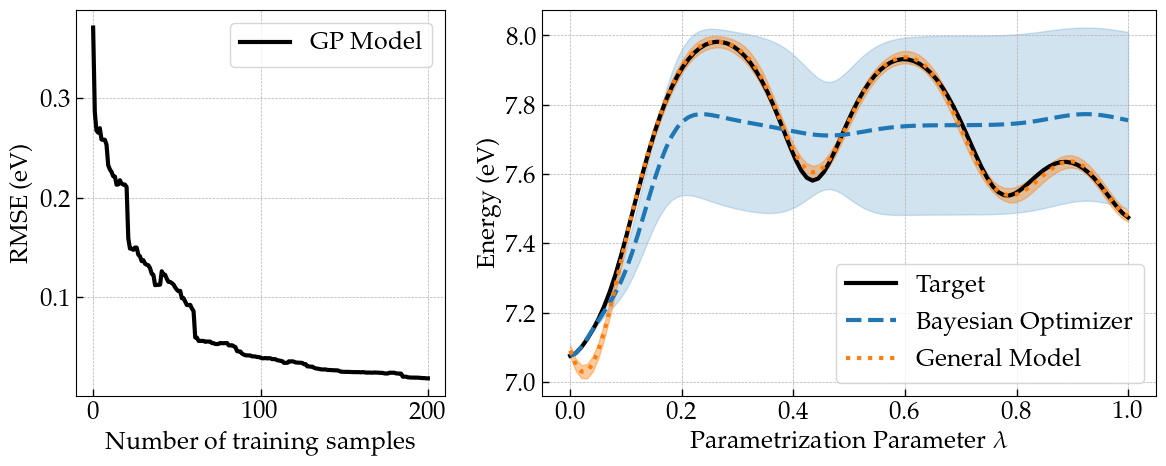

In [ ]:

# Plot RMSE convergence and energy predictions along path
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [0.6, 1]})

# RMSE convergence plot
axs[0].plot(np.arange(len(results['rmse_grid'])), results['rmse_grid'], label='GP Model', linewidth=3, color='k')
axs[0].set_xlabel('Number of training samples', fontsize=font_size)
axs[0].set_ylabel('RMSE (eV)', fontsize=font_size)
axs[0].legend(fontsize=font_size)
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].tick_params(axis='both', which='major', labelsize=font_size)

# Energy prediction along path plot
axs[1].plot(lam, target_energies, label='Target', color='black', linewidth=3)
axs[1].plot(lam, predicted_energies_bay.ravel(), label='Bayesian Optimizer', linestyle='--', linewidth=3)
axs[1].plot(lam, predicted_energies_gen.ravel(), label='General Model', linestyle=':', linewidth=3)
axs[1].fill_between(lam, 
                    predicted_energies_bay.ravel() - np.sqrt(predicted_vars_bay.ravel()),
                    predicted_energies_bay.ravel() + np.sqrt(predicted_vars_bay.ravel()),
                    color='tab:blue', alpha=0.2)
axs[1].fill_between(lam, 
                    predicted_energies_gen.ravel() - np.sqrt(predicted_vars_gen.ravel()),
                    predicted_energies_gen.ravel() + np.sqrt(predicted_vars_gen.ravel()),
                    color='tab:orange', alpha=0.4)
axs[1].set_xlabel('Parametrization Parameter $\\lambda$', fontsize=font_size)
axs[1].set_ylabel('Energy (eV)', fontsize=font_size)
axs[1].legend(fontsize=font_size)
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].tick_params(axis='both', which='major', labelsize=font_size)

plt.tight_layout()
# plt.savefig('figs/LBOS_energy_along_path.pdf')
plt.show()


---